In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
dataset = pd.read_csv('Exam_Score_Prediction.csv')

In [4]:
dataset.head()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,1,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,2,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,3,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,4,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,5,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [5]:
dataset.columns

Index(['student_id', 'age', 'gender', 'course', 'study_hours',
       'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality',
       'study_method', 'facility_rating', 'exam_difficulty', 'exam_score'],
      dtype='str')

In [6]:
dataset.describe()

,student_id,age,study_hours,class_attendance,sleep_hours,exam_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,10000.504600,20.473300,4.007604,70.017365,7.00856,62.513225
std,5773.654959,2.284458,2.308313,17.282262,1.73209,18.908491
min,1.000000,17.000000,0.080000,40.600000,4.10000,19.599000
25%,5000.750000,18.000000,2.000000,55.100000,5.50000,48.800000
50%,10000.500000,20.000000,4.040000,69.900000,7.00000,62.600000
75%,15000.250000,22.000000,6.000000,85.000000,8.50000,76.300000
max,20001.000000,24.000000,7.910000,99.400000,9.90000,100.000000


In [7]:
numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns

In [8]:
dataset.shape

(20000, 13)

In [9]:
numerical_cols

Index(['student_id', 'age', 'study_hours', 'class_attendance', 'sleep_hours',
       'exam_score'],
      dtype='str')

In [10]:
len(numerical_cols)

6

In [11]:
categorical_cols = dataset.select_dtypes(include=['object']).columns

C:\Users\Malik\AppData\Local\Temp\ipykernel_27248\1995621140.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = dataset.select_dtypes(include=['object']).columns


In [12]:
categorical_cols

Index(['gender', 'course', 'internet_access', 'sleep_quality', 'study_method',
       'facility_rating', 'exam_difficulty'],
      dtype='str')

In [13]:
dataset.dtypes

student_id            int64
age                   int64
gender                  str
course                  str
study_hours         float64
class_attendance    float64
internet_access         str
sleep_hours         float64
sleep_quality           str
study_method            str
facility_rating         str
exam_difficulty         str
exam_score          float64
dtype: object

In [14]:
dataset.isnull()

,student_id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,False,False,False,False,False,False,False,False,False,False,False,False,False
19996,False,False,False,False,False,False,False,False,False,False,False,False,False
19997,False,False,False,False,False,False,False,False,False,False,False,False,False
19998,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
dataset.isnull().values.any()

np.False_

In [16]:
dataset.isnull().values.sum()

np.int64(0)

In [17]:
dataset.shape

(20000, 13)

In [18]:
dataset.columns[dataset.isnull().any()]

Index([], dtype='str')

In [19]:
len(dataset.columns[dataset.isnull().any()])

0

In [20]:
dataset.select_dtypes(include=['int64','float64']).columns[dataset.select_dtypes(include=['int64','float64']).isnull().any()]

Index([], dtype='str')

In [21]:
len(dataset.columns[dataset.isnull().any()])

0

In [22]:

dataset['gender'].mode()

0    other
Name: gender, dtype: str

In [23]:
len(dataset.columns[dataset.isnull().any()])

0

In [24]:
dataset.isnull().values.any()

np.False_

In [25]:
dataset = dataset.drop(['student_id'], axis=1)

In [26]:
dataset.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,17,male,diploma,2.78,92.9,yes,7.4,poor,coaching,low,hard,58.9
1,23,other,bca,3.37,64.8,yes,4.6,average,online videos,medium,moderate,54.8
2,22,male,b.sc,7.88,76.8,yes,8.5,poor,coaching,high,moderate,90.3
3,20,other,diploma,0.67,48.4,yes,5.8,average,online videos,low,moderate,29.7
4,20,female,diploma,0.89,71.6,yes,9.8,poor,coaching,low,moderate,43.7


In [27]:
dataset.shape

(20000, 12)

In [28]:
dataset = pd.get_dummies(dataset, drop_first=True)

In [29]:
dataset.head()

,age,study_hours,class_attendance,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,course_ba,course_bba,course_bca,course_diploma,internet_access_yes,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,17,2.78,92.9,7.4,58.9,True,False,False,False,False,False,False,True,True,False,True,False,False,False,False,True,False,True,False
1,23,3.37,64.8,4.6,54.8,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,True,False,True
2,22,7.88,76.8,8.5,90.3,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True
3,20,0.67,48.4,5.8,29.7,False,True,False,False,False,False,False,True,True,False,False,False,False,True,False,True,False,False,True
4,20,0.89,71.6,9.8,43.7,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,True,False,False,True


<Axes: xlabel='exam_score', ylabel='Count'>

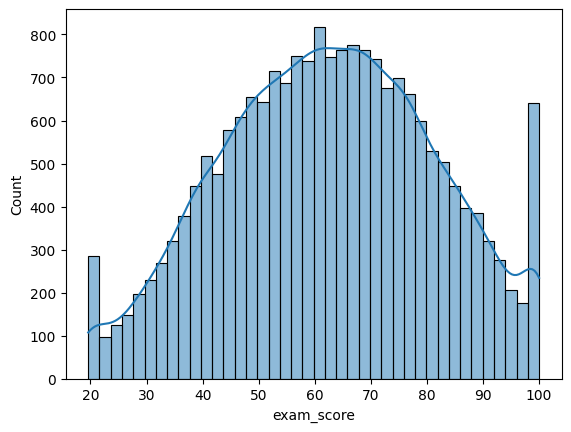

In [30]:
sns.histplot(dataset['exam_score'], kde=True)

C:\Users\Malik\AppData\Local\Temp\ipykernel_27248\3984473378.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset[dataset['exam_difficulty_hard']==0]['study_hours'],hist=False)
C:\Users\Malik\AppData\Local\Temp\ipykernel_27248\3984473378.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe57

<Axes: xlabel='study_hours', ylabel='Density'>

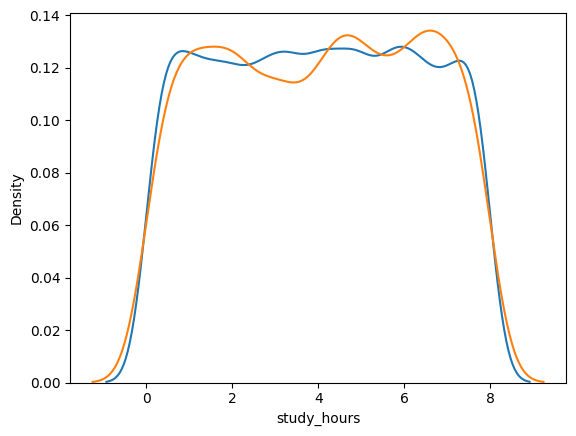

In [31]:
sns.distplot(dataset[dataset['exam_difficulty_hard']==0]['study_hours'],hist=False)
sns.distplot(dataset[dataset['exam_difficulty_hard']==1]['study_hours'],hist=False)

<Axes: xlabel='exam_score'>

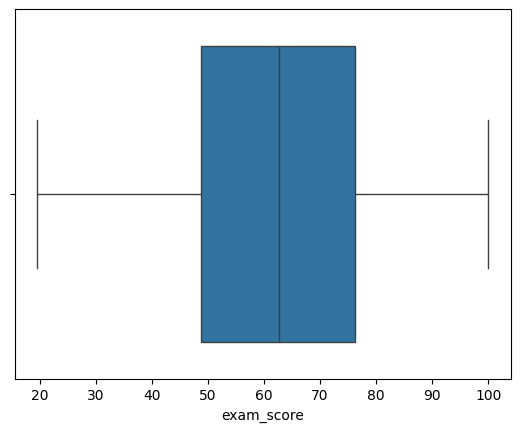

In [32]:
sns.boxplot(x=dataset['exam_score'])

<Axes: xlabel='study_hours', ylabel='exam_score'>

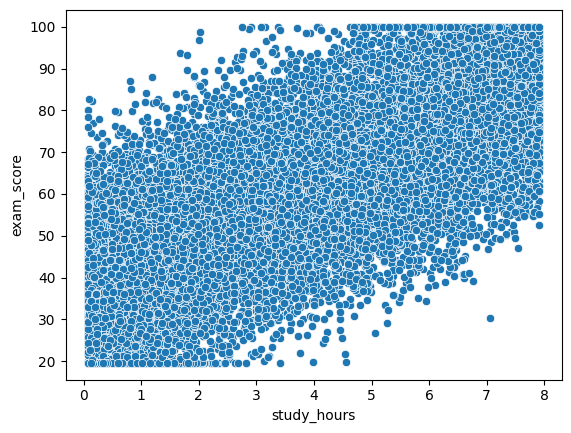

In [33]:
sns.scatterplot(x=dataset['study_hours'], y=dataset['exam_score'])

In [34]:
correlations = dataset.corr()

In [35]:
plt.figure(figsize=(15, 10))

<Figure size 1500x1000 with 0 Axes>

<Figure size 1500x1000 with 0 Axes>

<Axes: >

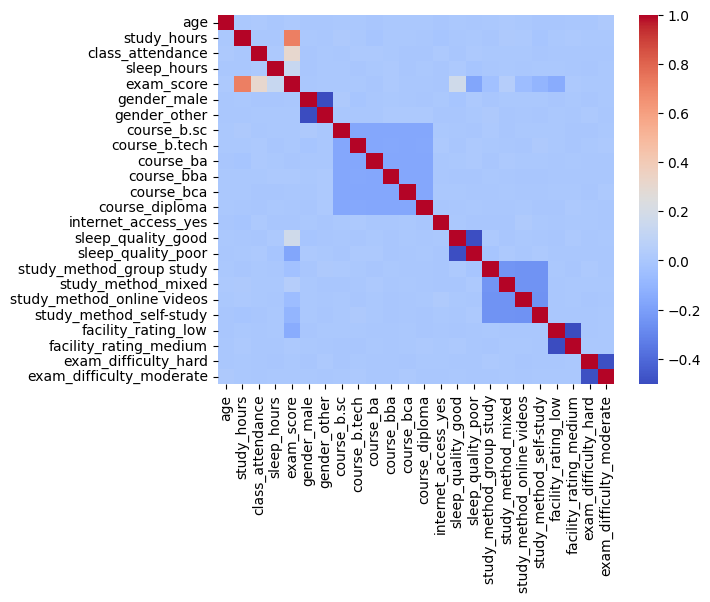

In [36]:
sns.heatmap(correlations, annot=False, cmap='coolwarm')

In [37]:
correlations['exam_score'].sort_values(ascending=False)

exam_score                    1.000000
study_hours                   0.717788
class_attendance              0.308850
sleep_quality_good            0.172049
sleep_hours                   0.133222
study_method_mixed            0.044980
facility_rating_medium        0.010613
course_bba                    0.008920
age                           0.006522
course_b.sc                   0.004462
exam_difficulty_hard          0.003068
course_b.tech                 0.002993
gender_other                  0.001799
exam_difficulty_moderate      0.001779
course_bca                    0.000236
course_diploma               -0.003917
gender_male                  -0.004342
internet_access_yes          -0.007826
course_ba                    -0.008727
study_method_group study     -0.040377
study_method_online videos   -0.063120
study_method_self-study      -0.101278
facility_rating_low          -0.146083
sleep_quality_poor           -0.172257
Name: exam_score, dtype: float64

In [38]:
x = dataset.drop('exam_score', axis=1)

In [39]:
y = dataset['exam_score']

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
regressor_mlr = LinearRegression()
regressor_mlr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [55]:
y_pred = regressor_mlr.predict(x_test)
y_pred.shape

(4000,)

In [49]:
from sklearn.metrics import r2_score

In [50]:
r2_score(y_test, y_pred)

0.7330084088180805

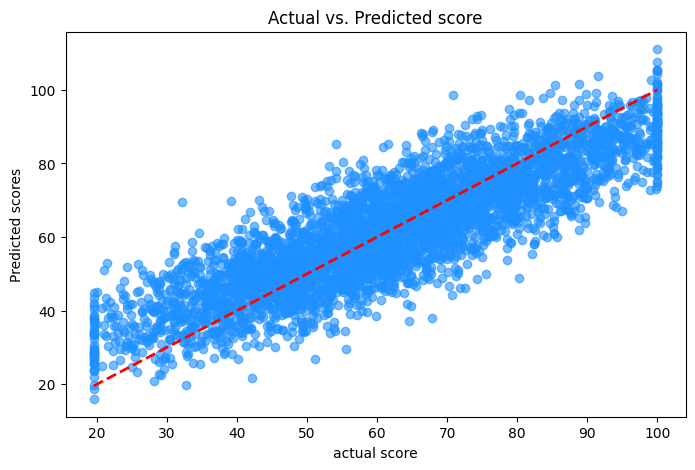

In [54]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_train.max()], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted score')
plt.xlabel('actual score')
plt.ylabel('Predicted scores')
plt.show()